In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    learning_curve
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)


In [2]:
# Loading Dataset
dataset = pd.read_csv("ui_training_dataset.csv")
dataset.head()

,nodeCount,screenWidth,screenHeight,screenArea,isModalLike,modalConfidence,hasExitControl,hasDestructiveAction,hasUndoOption,hasConfirmationDialog,...,module_color,module_error,module_normal,designId,category,screenType,theme,issueLabel,severity,suggestionCategory
0,8.0,430.0,932.0,400760.0,1.0,0.75,1.0,1.0,1.0,0.0,...,1.0,0.0,0.0,color_00001,color,reset_confirmation,Dark,same_color_different_actions,medium,differentiate_action_colors
1,15.0,1366.0,768.0,1049088.0,0.0,0.00,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,color_00002,color,register,Light Blue,weak_error_visibility,medium,improve_error_state_visibility
2,8.0,390.0,844.0,329160.0,1.0,0.75,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,color_00003,color,delete_confirmation,Green,weak_error_visibility,medium,improve_error_state_visibility
3,18.0,1920.0,1080.0,2073600.0,0.0,0.00,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,color_00004,color,settings,Green,same_color_different_actions,medium,differentiate_action_colors
4,8.0,1920.0,1080.0,2073600.0,1.0,0.75,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,color_00005,color,delete_confirmation,Light Blue,same_color_different_actions,medium,differentiate_action_colors


In [3]:
# Dataset Structure
print("Dataset shape:", dataset.shape)
dataset.info()


Dataset shape: (40000, 49)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 49 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   nodeCount                      40000 non-null  float64
 1   screenWidth                    40000 non-null  float64
 2   screenHeight                   40000 non-null  float64
 3   screenArea                     40000 non-null  float64
 4   isModalLike                    40000 non-null  float64
 5   modalConfidence                40000 non-null  float64
 6   hasExitControl                 40000 non-null  float64
 7   hasDestructiveAction           40000 non-null  float64
 8   hasUndoOption                  40000 non-null  float64
 9   hasConfirmationDialog          40000 non-null  float64
 10  interactiveElementCount        40000 non-null  float64
 11  textElementCount               40000 non-null  float64
 12  errorElementCount  

In [4]:
# Prepare Features & Target Variables
TARGET_COLUMNS = [
    "issueLabel",
    "severity",
    "suggestionCategory",
]

FEATURE_COLUMNS = [
    column
    for column in dataset.select_dtypes(include=["number", "bool"]).columns
    if column not in TARGET_COLUMNS
]

X = dataset[FEATURE_COLUMNS].copy()
y = dataset[TARGET_COLUMNS].copy()

X = X.astype(float)
X = X.fillna(X.median())

for target in TARGET_COLUMNS:
    if y[target].isna().any():
        raise ValueError(f"Target column '{target}' contains missing values.")
    y[target] = y[target].astype(str)

print(f"Number of input features: {len(FEATURE_COLUMNS)}")
print("Targets:", TARGET_COLUMNS)


Number of input features: 42
Targets: ['issueLabel', 'severity', 'suggestionCategory']


In [5]:
# Perform 5 fold cross validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

cross_validation_results = []

for target in TARGET_COLUMNS:
    print("=" * 70)
    print(f"5-FOLD CROSS-VALIDATION: {target}")
    print("=" * 70)

    cv_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
    )

    scores = cross_validate(
        estimator=cv_model,
        X=X,
        y=y[target],
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "precision": "precision_weighted",
            "f1": "f1_weighted",
        },
        n_jobs=-1,
        return_train_score=False,
    )

    accuracy_scores = scores["test_accuracy"]
    precision_scores = scores["test_precision"]
    f1_scores = scores["test_f1"]

    print("Fold accuracy scores :", np.round(accuracy_scores, 4))
    print("Fold precision scores:", np.round(precision_scores, 4))
    print("Fold F1 scores       :", np.round(f1_scores, 4))

    print()
    print("Average cross-validation results:")
    print(f"Accuracy : {accuracy_scores.mean():.4f} ± {accuracy_scores.std():.4f}")
    print(f"Precision: {precision_scores.mean():.4f} ± {precision_scores.std():.4f}")
    print(f"F1 Score : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")
    print()

    for fold_number in range(5):
        cross_validation_results.append({
            "Target": target,
            "Fold": fold_number + 1,
            "Accuracy": accuracy_scores[fold_number],
            "Precision": precision_scores[fold_number],
            "F1 Score": f1_scores[fold_number],
        })


5-FOLD CROSS-VALIDATION: issueLabel
Fold accuracy scores : [0.7094 0.717  0.7329 0.7211 0.719 ]
Fold precision scores: [0.7133 0.719  0.7357 0.7255 0.7215]
Fold F1 scores       : [0.7107 0.7174 0.7339 0.7225 0.7198]

Average cross-validation results:
Accuracy : 0.7199 ± 0.0076
Precision: 0.7230 ± 0.0075
F1 Score : 0.7209 ± 0.0076

5-FOLD CROSS-VALIDATION: severity
Fold accuracy scores : [1. 1. 1. 1. 1.]
Fold precision scores: [1. 1. 1. 1. 1.]
Fold F1 scores       : [1. 1. 1. 1. 1.]

Average cross-validation results:
Accuracy : 1.0000 ± 0.0000
Precision: 1.0000 ± 0.0000
F1 Score : 1.0000 ± 0.0000

5-FOLD CROSS-VALIDATION: suggestionCategory
Fold accuracy scores : [0.7098 0.7141 0.7322 0.7269 0.7171]
Fold precision scores: [0.7132 0.7165 0.7359 0.732  0.7189]
Fold F1 scores       : [0.7109 0.7145 0.7333 0.7284 0.7176]

Average cross-validation results:
Accuracy : 0.7200 ± 0.0083
Precision: 0.7233 ± 0.0090
F1 Score : 0.7209 ± 0.0085



In [6]:
# Display results by fold
cv_results_dataframe = pd.DataFrame(cross_validation_results)

cv_results_dataframe.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "F1 Score": "{:.4f}",
})


,Target,Fold,Accuracy,Precision,F1 Score
0,issueLabel,1,0.7094,0.7133,0.7107
1,issueLabel,2,0.7170,0.7190,0.7174
2,issueLabel,3,0.7329,0.7357,0.7339
3,issueLabel,4,0.7211,0.7255,0.7225
4,issueLabel,5,0.7190,0.7215,0.7198
5,severity,1,1.0000,1.0000,1.0000
6,severity,2,1.0000,1.0000,1.0000
7,severity,3,1.0000,1.0000,1.0000
8,severity,4,1.0000,1.0000,1.0000
9,severity,5,1.0000,1.0000,1.0000


In [7]:
# Summarize Validation Performance
cv_summary = (
    cv_results_dataframe
    .groupby("Target")
    .agg(
        Mean_Accuracy=("Accuracy", "mean"),
        Accuracy_Std=("Accuracy", "std"),
        Mean_Precision=("Precision", "mean"),
        Precision_Std=("Precision", "std"),
        Mean_F1=("F1 Score", "mean"),
        F1_Std=("F1 Score", "std"),
    )
    .reset_index()
)

cv_percentage_summary = cv_summary.copy()
metric_columns = [
    "Mean_Accuracy",
    "Accuracy_Std",
    "Mean_Precision",
    "Precision_Std",
    "Mean_F1",
    "F1_Std",
]

cv_percentage_summary[metric_columns] = (
    cv_percentage_summary[metric_columns] * 100
).round(2)

cv_percentage_summary = cv_percentage_summary.rename(columns={
    "Mean_Accuracy": "Mean Accuracy (%)",
    "Accuracy_Std": "Accuracy Std (%)",
    "Mean_Precision": "Mean Precision (%)",
    "Precision_Std": "Precision Std (%)",
    "Mean_F1": "Mean F1 Score (%)",
    "F1_Std": "F1 Std (%)",
})

cv_percentage_summary


,Target,Mean Accuracy (%),Accuracy Std (%),Mean Precision (%),Precision Std (%),Mean F1 Score (%),F1 Std (%)
0,issueLabel,71.99,0.85,72.30,0.84,72.09,0.85
1,severity,100.00,0.00,100.00,0.00,100.00,0.00
2,suggestionCategory,72.00,0.93,72.33,1.00,72.09,0.95


LEARNING CURVE: issueLabel


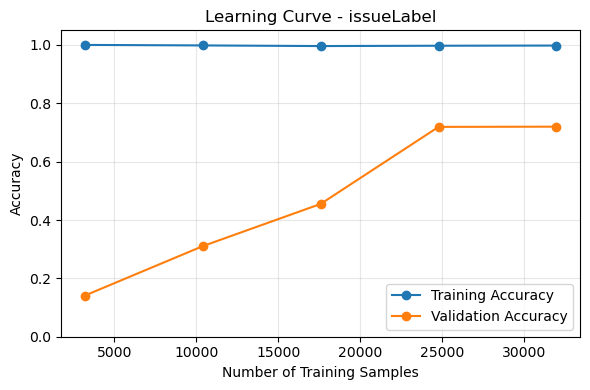

LEARNING CURVE: severity


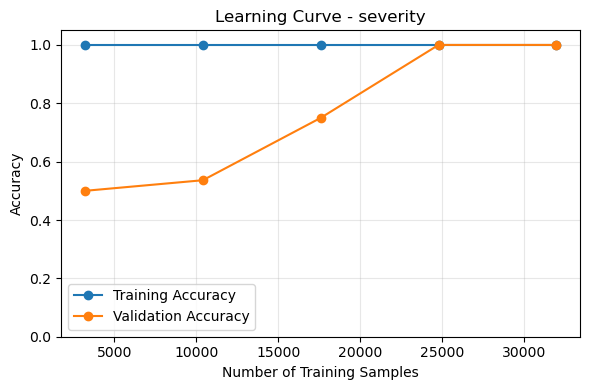

LEARNING CURVE: suggestionCategory


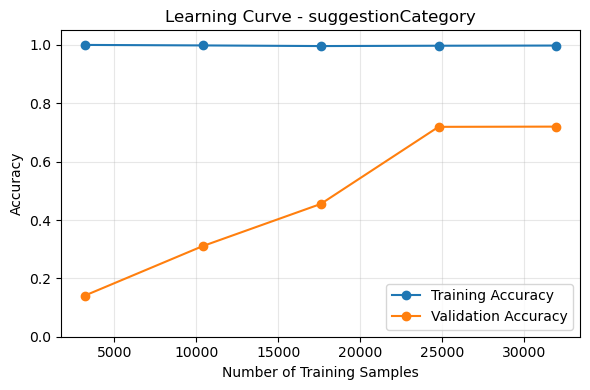

In [8]:
# Generate Learning Curves

learning_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_sizes = np.linspace(0.1, 1.0, 5)

for target in TARGET_COLUMNS:

    print("=" * 60)
    print(f"LEARNING CURVE: {target}")
    print("=" * 60)

    learning_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    sizes, train_scores, validation_scores = learning_curve(
        estimator=learning_model,
        X=X,
        y=y[target],
        cv=learning_cv,
        train_sizes=train_sizes,
        scoring="accuracy",
        n_jobs=-1
    )

    train_mean = np.mean(
        train_scores,
        axis=1
    )

    validation_mean = np.mean(
        validation_scores,
        axis=1
    )

    plt.figure(figsize=(6, 4))

    plt.plot(
        sizes,
        train_mean,
        marker="o",
        label="Training Accuracy"
    )

    plt.plot(
        sizes,
        validation_mean,
        marker="o",
        label="Validation Accuracy"
    )

    plt.title(
        f"Learning Curve - {target}"
    )

    plt.xlabel(
        "Number of Training Samples"
    )

    plt.ylabel(
        "Accuracy"
    )

    plt.ylim(
        0,
        1.05
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

In [9]:
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y["issueLabel"],
)

print("Training set shape:", X_train.shape)
print("Testing set shape :", X_test.shape)


Training set shape: (32000, 42)
Testing set shape : (8000, 42)


In [10]:
# Train Random Forest Model
forest = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
)

model = MultiOutputClassifier(
    estimator=forest,
    n_jobs=-1,
)

model.fit(X_train, y_train)
print("Final model training completed.")


Final model training completed.


In [11]:
# Generate Predictions
predictions = model.predict(X_test)

prediction_df = pd.DataFrame(
    predictions,
    columns=TARGET_COLUMNS,
    index=y_test.index,
)

prediction_df.head()


,issueLabel,severity,suggestionCategory
31744,no_issue,low,no_action_needed
5946,color_inconsistency,medium,standardize_action_color
4192,weak_error_visibility,medium,improve_error_state_visibility
36184,no_issue,low,no_action_needed
35696,no_issue,low,no_action_needed


In [14]:
# Compare Training and Testing Accuracy for All Three Targets

# Predictions on training data
train_predictions = model.predict(X_train)

# Predictions on testing data
test_predictions = model.predict(X_test)

train_prediction_df = pd.DataFrame(
    train_predictions,
    columns=TARGET_COLUMNS,
    index=y_train.index
)

test_prediction_df = pd.DataFrame(
    test_predictions,
    columns=TARGET_COLUMNS,
    index=y_test.index
)

accuracy_comparison = []

for target in TARGET_COLUMNS:

    train_accuracy = accuracy_score(
        y_train[target],
        train_prediction_df[target]
    )

    test_accuracy = accuracy_score(
        y_test[target],
        test_prediction_df[target]
    )

    accuracy_comparison.append({
        "Target": target,
        "Training Accuracy (%)": round(train_accuracy * 100, 2),
        "Testing Accuracy (%)": round(test_accuracy * 100, 2)
    })

accuracy_comparison_df = pd.DataFrame(
    accuracy_comparison
)

accuracy_comparison_df

,Target,Training Accuracy (%),Testing Accuracy (%)
0,issueLabel,99.79,71.90
1,severity,100.00,100.00
2,suggestionCategory,99.79,71.71


In [12]:
# Evaluate Model Performance
test_results = []

for target in TARGET_COLUMNS:
    accuracy = accuracy_score(y_test[target], prediction_df[target])
    precision = precision_score(
        y_test[target],
        prediction_df[target],
        average="weighted",
        zero_division=0,
    )
    f1 = f1_score(
        y_test[target],
        prediction_df[target],
        average="weighted",
        zero_division=0,
    )

    test_results.append({
        "Target": target,
        "Accuracy (%)": accuracy * 100,
        "Precision (%)": precision * 100,
        "F1 Score (%)": f1 * 100,
    })

test_results_dataframe = pd.DataFrame(test_results)

test_results_dataframe.style.format({
    "Accuracy (%)": "{:.2f}",
    "Precision (%)": "{:.2f}",
    "F1 Score (%)": "{:.2f}",
})


,Target,Accuracy (%),Precision (%),F1 Score (%)
0,issueLabel,71.90,72.02,71.93
1,severity,100.00,100.00,100.00
2,suggestionCategory,71.71,71.85,71.74


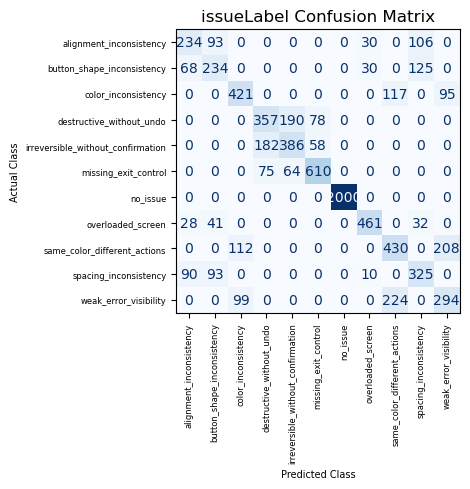

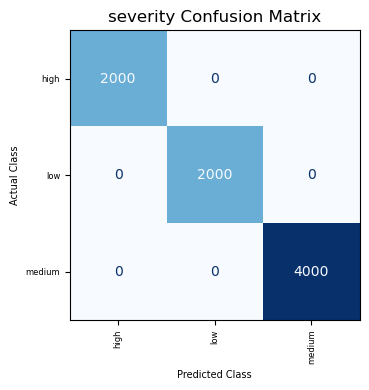

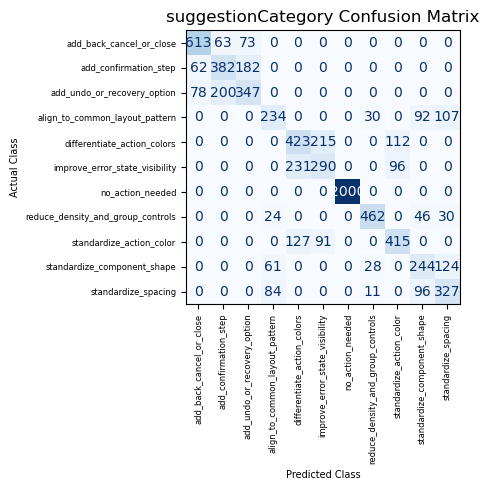

In [13]:
# Generate Confusion Matrices
for target in TARGET_COLUMNS:
    labels = sorted(y_test[target].unique())

    cm = confusion_matrix(
        y_test[target],
        prediction_df[target],
        labels=labels,
    )

    if target == "issueLabel":
        figsize = (6, 5)
    elif target == "severity":
        figsize = (5, 4)
    else:
        figsize = (6, 5)
    
    figure, axis = plt.subplots(figsize=figsize)

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels,
    )

    display.plot(
        ax=axis,
        cmap="Blues",
        xticks_rotation=90,
        values_format="d",
        colorbar=False,
    )

    axis.tick_params(axis="x", labelsize=6)
    axis.tick_params(axis="y", labelsize=6)
    
    axis.xaxis.label.set_size(7)
    axis.yaxis.label.set_size(7)
    
    axis.title.set_size(8)

    axis.set_title(f"{target} Confusion Matrix")
    axis.set_xlabel("Predicted Class")
    axis.set_ylabel("Actual Class")

    plt.tight_layout()
    plt.show()
